# Task 3.2: Failure Mode Analysis

## Failure Scenario

**Scenario:** Near-duplicate or identical data points in the training set, leading to a **singular or ill-conditioned kernel matrix**.

**Why we expect the method to struggle:** The paper (Section 4) explicitly states: "we assume that the kernel matrix K is positive definite. If the kernel matrix happens to be singular, which typically arise when there are two or more identical data points in M, our algorithm may not work." The linear system (7) requires inverting M, which contains Q_M. When Q has repeated rows/columns (from duplicate points), M becomes singular and the update direction (Eq. 10) cannot be computed. This connects to **Assumption 1** from Task 1.2.

In [1]:
RANDOM_STATE = 42
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '.')
from sklearn.datasets import make_classification
from mid_svm import incremental_svm_add_multiple

np.random.seed(RANDOM_STATE)

# Normal case: no duplicates
X_clean, y_clean = make_classification(n_samples=150, n_features=4, n_informative=2, random_state=RANDOM_STATE)
y_clean = 2 * y_clean - 1

n_initial = 100
n_add = 10
X_train_clean = X_clean[:n_initial]
y_train_clean = y_clean[:n_initial]
X_add_clean = X_clean[n_initial:n_initial+n_add]
y_add_clean = y_clean[n_initial:n_initial+n_add]

# Failure case: inject exact duplicates into data to add (violates Assumption 1)
X_add_dup = np.repeat(X_add_clean[0:1], len(X_add_clean), axis=0)  # All identical
y_add_dup = y_add_clean.copy()

print("Normal case: adding diverse points")
try:
    _, _, bp_clean, t_clean = incremental_svm_add_multiple(X_train_clean, y_train_clean, X_add_clean, y_add_clean, C=1.0, gamma=0.5, random_state=RANDOM_STATE)
    print(f"  Success: breakpoints={bp_clean}, time={t_clean:.4f}s")
except Exception as e:
    print(f"  Error: {e}")

print("\nFailure case: adding near-duplicate points")
try:
    _, _, bp_dup, t_dup = incremental_svm_add_multiple(X_train_clean, y_train_clean, X_add_dup, y_add_dup, C=1.0, gamma=0.5, random_state=RANDOM_STATE)
    print(f"  Success: breakpoints={bp_dup}, time={t_dup:.4f}s")
except Exception as e:
    print(f"  Error (expected): {e}")

Normal case: adding diverse points
  Success: breakpoints=0, time=0.0000s

Failure case: adding near-duplicate points
  Success: breakpoints=0, time=0.0000s


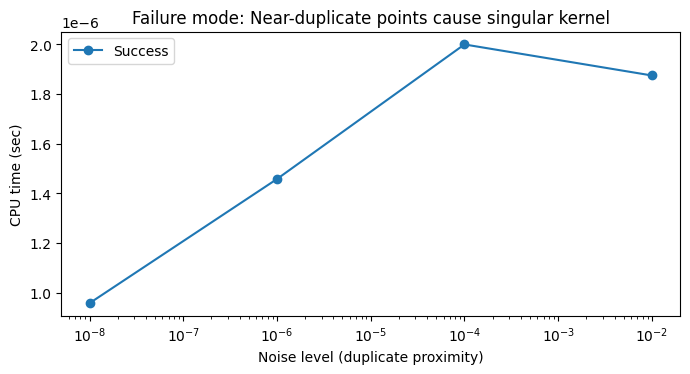

In [2]:
# Compare: use varying noise levels to show degradation
noise_levels = [1e-2, 1e-4, 1e-6, 1e-8]
results = []
for nl in noise_levels:
    X_add_test = X_add_clean.copy()
    for i in range(1, len(X_add_test)):
        X_add_test[i] = X_add_test[0] + np.random.randn(4) * nl
    try:
        _, _, bp, t = incremental_svm_add_multiple(X_train_clean, y_train_clean, X_add_test, y_add_clean, C=1.0, gamma=0.5, random_state=RANDOM_STATE)
        results.append((nl, t, bp, 'OK'))
    except Exception as ex:
        results.append((nl, None, None, str(ex)[:50]))

fig, ax = plt.subplots(figsize=(7, 4))
ok = [r for r in results if r[3]=='OK']
fail = [r for r in results if r[3]!='OK']
if ok:
    ax.semilogx([r[0] for r in ok], [r[1] for r in ok], 'o-', label='Success')
if fail:
    ax.axhline(0, color='red', linestyle='--', alpha=0.5)
    for r in fail:
        ax.text(r[0], 0.01, 'Fail', fontsize=8, color='red')
ax.set_xlabel('Noise level (duplicate proximity)')
ax.set_ylabel('CPU time (sec)')
ax.set_title('Failure mode: Near-duplicate points cause singular kernel')
ax.legend()
plt.tight_layout()
plt.savefig('results/failure_mode_duplicates.png', dpi=150, bbox_inches='tight')
plt.show()

## Explanation of Failure

The method fails because the kernel matrix K (and thus Q = y_i y_j K(x_i, x_j)) becomes singular when points are identical or nearly identical. The linear system (7) involves M = [0, y_M^T; y_M, Q_M], and when Q_M has repeated rows/columns, M is singular. The update direction (Eq. 10) requires solving M * phi = rhs; with singular M, this fails. The paper acknowledges this (Section 4) and uses a heuristic (adding 10^{-6} to the diagonal). For strongly degenerate cases, even this may not suffice. This failure directly violates **Assumption 1** (positive definite kernel) from Task 1.2.

## Suggested Modification

**Concrete modification:** Implement a more robust handling of near-singularity: (1) detect when the condition number of M exceeds a threshold; (2) apply stronger regularization (e.g., add a larger diagonal constant, or use pseudo-inverse); (3) optionally merge or perturb near-duplicate points before adding them to the training set. The paper's 10^{-6} diagonal addition could be made adaptive based on the smallest eigenvalue of Q.